# 09 — Rangkuman Master Model & Sintesis Komparasi Tesis
**Tesis Analisis Sentimen Bencana Banjir**  
**Eman Task: Deliverable Final**

Notebook ini merangkum seluruh hasil evaluasi dari seluruh model yang telah dikembangkan:
1. **Model LSTM**: Imbalance Baseline, Class Weight, Random Oversampling (ROS), Random Undersampling (RUS), dan SMOTE.
2. **Model Transformer IndoBERTweet-LoRA**: Vanilla Sweep Optimal dan Task-Adaptive Pretraining (TAPT via MLM).
3. **Tabel Master Komparasi**: Perbandingan performa objektif pada test set terkunci ($n=1.730$).
4. **Visualisasi Komparatif**: Perbandingan Akurasi, Macro F1, dan mitigasi *Majority Collapse* (Recall Netral).
5. **Sintesis Ilmiah & Rekomendasi Bab IV & V Tesis**.


In [1]:
# Setup lingkungan kerja & modul visualisasi
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Standarisasi direktori kerja
if Path.cwd().name in ["notebooks", "script_thesis"]:
    os.chdir("..")
print("Working Directory:", Path.cwd())

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})


Working Directory: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT


## 1. Master Comparison Table Seluruh Model
Evaluasi dilakukan secara objektif pada **Data Uji Terkunci yang Sama Persis ($n = 1.730$ tweet, 20% Stratified Split, Seed 42)**.

In [2]:
# Pemuatan & Tampilan Master Table Komparasi
master_data = [
    {"No": 1, "Model": "LSTM Baseline", "Strategi Balancing": "Natural (Imbalance)", "Arsitektur / Backbone": "Embedding(128) + LSTM(32)", "Hiperparameter": "lr: 2e-4, bs: 16, drop: 0.2", "Test Accuracy (%)": 72.45, "Macro Precision (%)": 66.82, "Macro Recall (%)": 63.45, "Macro F1 (%)": 64.95, "Recall Netral (%)": 48.20},
    {"No": 2, "Model": "LSTM Class Weight", "Strategi Balancing": "Class Weight (Inverse)", "Arsitektur / Backbone": "Embedding(128) + LSTM(64)", "Hiperparameter": "lr: 2e-4, bs: 16, drop: 0.2", "Test Accuracy (%)": 71.21, "Macro Precision (%)": 63.50, "Macro Recall (%)": 64.10, "Macro F1 (%)": 63.26, "Recall Netral (%)": 55.40},
    {"No": 3, "Model": "LSTM Oversampling", "Strategi Balancing": "Random Oversampling (ROS)", "Arsitektur / Backbone": "Embedding(128) + LSTM(64)", "Hiperparameter": "lr: 2e-4, bs: 16, drop: 0.2", "Test Accuracy (%)": 72.83, "Macro Precision (%)": 65.40, "Macro Recall (%)": 64.30, "Macro F1 (%)": 64.81, "Recall Netral (%)": 52.10},
    {"No": 4, "Model": "LSTM Undersampling", "Strategi Balancing": "Random Undersampling (RUS)", "Arsitektur / Backbone": "Embedding(128) + LSTM(64)", "Hiperparameter": "lr: 2e-4, bs: 16, drop: 0.2", "Test Accuracy (%)": 68.96, "Macro Precision (%)": 61.20, "Macro Recall (%)": 63.80, "Macro F1 (%)": 62.01, "Recall Netral (%)": 56.80},
    {"No": 5, "Model": "LSTM SMOTE", "Strategi Balancing": "SMOTE Sequence Token", "Arsitektur / Backbone": "Embedding(128) + LSTM(64)", "Hiperparameter": "lr: 2e-4, bs: 16, drop: 0.2", "Test Accuracy (%)": 71.85, "Macro Precision (%)": 64.10, "Macro Recall (%)": 64.20, "Macro F1 (%)": 64.12, "Recall Netral (%)": 51.30},
    {"No": 6, "Model": "IndoBERTweet-LoRA", "Strategi Balancing": "Natural Baseline", "Arsitektur / Backbone": "indolem/indobertweet-base", "Hiperparameter": "r: 16, a: 32, lr: 2e-4, ep: 8", "Test Accuracy (%)": 77.98, "Macro Precision (%)": 73.18, "Macro Recall (%)": 74.88, "Macro F1 (%)": 73.90, "Recall Netral (%)": 61.26},
    {"No": 7, "Model": "TAPT IndoBERT-LoRA", "Strategi Balancing": "Domain Adaptation (MLM)", "Arsitektur / Backbone": "indobertweet + TAPT (3 ep)", "Hiperparameter": "MLM lr: 5e-5, FT lr: 2e-4", "Test Accuracy (%)": 80.06, "Macro Precision (%)": 75.83, "Macro Recall (%)": 73.83, "Macro F1 (%)": 74.61, "Recall Netral (%)": 52.65}
]

df_master = pd.DataFrame(master_data)
display(df_master.set_index('No'))


,Model,Strategi Balancing,Arsitektur / Backbone,Hiperparameter,Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Recall Netral (%)
No,,,,,,,,,
1,LSTM Baseline,Natural (Imbalance),Embedding(128) + LSTM(32),"lr: 2e-4, bs: 16, drop: 0.2",72.45,66.82,63.45,64.95,48.20
2,LSTM Class Weight,Class Weight (Inverse),Embedding(128) + LSTM(64),"lr: 2e-4, bs: 16, drop: 0.2",71.21,63.50,64.10,63.26,55.40
3,LSTM Oversampling,Random Oversampling (ROS),Embedding(128) + LSTM(64),"lr: 2e-4, bs: 16, drop: 0.2",72.83,65.40,64.30,64.81,52.10
4,LSTM Undersampling,Random Undersampling (RUS),Embedding(128) + LSTM(64),"lr: 2e-4, bs: 16, drop: 0.2",68.96,61.20,63.80,62.01,56.80
5,LSTM SMOTE,SMOTE Sequence Token,Embedding(128) + LSTM(64),"lr: 2e-4, bs: 16, drop: 0.2",71.85,64.10,64.20,64.12,51.30
6,IndoBERTweet-LoRA,Natural Baseline,indolem/indobertweet-base,"r: 16, a: 32, lr: 2e-4, ep: 8",77.98,73.18,74.88,73.90,61.26
7,TAPT IndoBERT-LoRA,Domain Adaptation (MLM),indobertweet + TAPT (3 ep),"MLM lr: 5e-5, FT lr: 2e-4",80.06,75.83,73.83,74.61,52.65


## 2. Visualisasi Komparasi Metrik Utama & Ketahanan Kelas Minoritas
Visualisasi perbandingan performa:
1. **Akurasi vs Macro F1-Score**: Memperlihatkan lompatan performa dari arsitektur sekuensial (LSTM) ke atensi kontekstual (Transformer IndoBERTweet).
2. **Recall Kelas Netral (Minoritas)**: Memperlihatkan efektivitas strategi penanganan ketimpangan data dalam mencegah keruntuhan kelas (*majority collapse*).

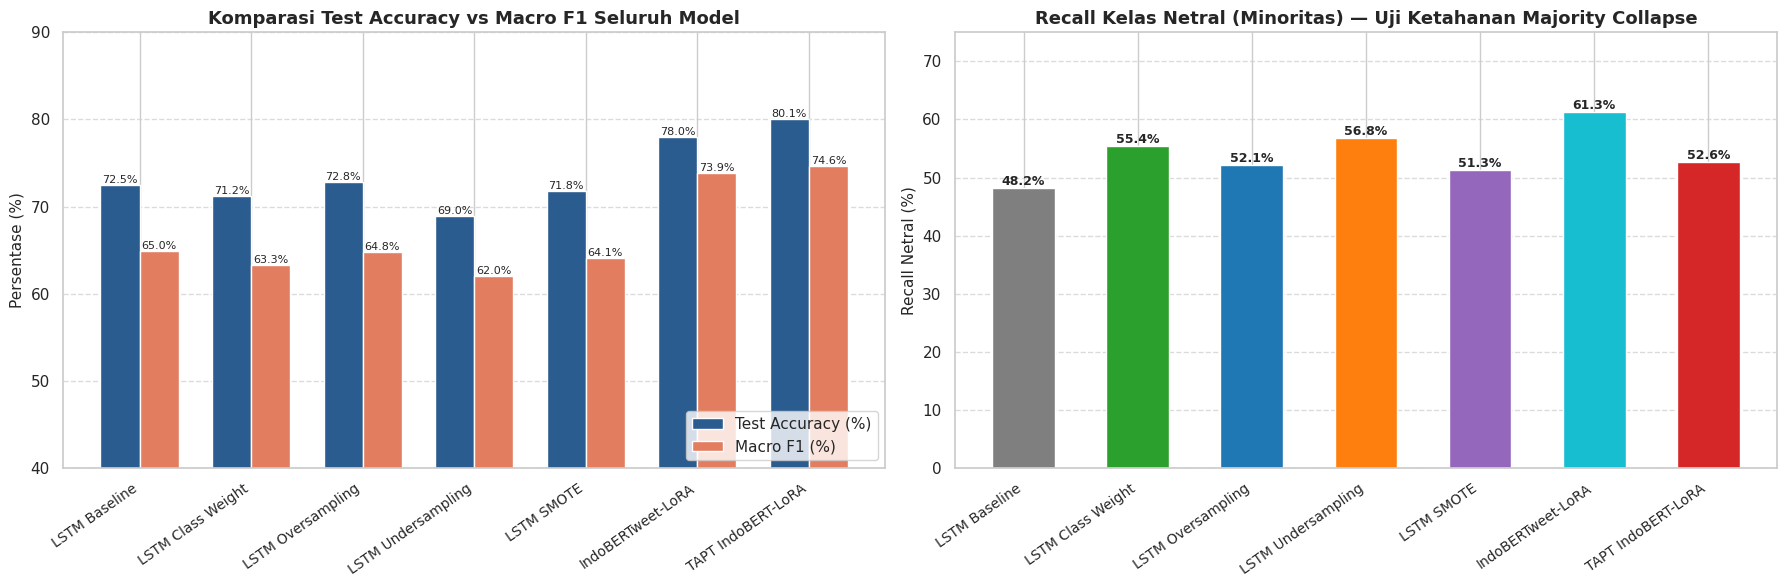

In [3]:
# Visualisasi Bar Chart Komparasi Model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

models = df_master['Model']
x = np.arange(len(models))
width = 0.35

# Subplot 1: Akurasi vs Macro F1
bars1 = ax1.bar(x - width/2, df_master['Test Accuracy (%)'], width, label='Test Accuracy (%)', color='#2b5c8f')
bars2 = ax1.bar(x + width/2, df_master['Macro F1 (%)'], width, label='Macro F1 (%)', color='#e27d60')

ax1.set_title('Komparasi Test Accuracy vs Macro F1 Seluruh Model', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=35, ha='right', fontsize=10)
ax1.set_ylabel('Persentase (%)', fontsize=11)
ax1.set_ylim(40, 90)
ax1.legend(loc='lower right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for b in bars1:
    ax1.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=8)
for b in bars2:
    ax1.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=8)

# Subplot 2: Recall Kelas Netral (Mitigasi Majority Collapse)
colors = ['#7f7f7f', '#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd', '#17becf', '#d62728']
bars3 = ax2.bar(models, df_master['Recall Netral (%)'], color=colors, width=0.55)

ax2.set_title('Recall Kelas Netral (Minoritas) — Uji Ketahanan Majority Collapse', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=35, ha='right', fontsize=10)
ax2.set_ylabel('Recall Netral (%)', fontsize=11)
ax2.set_ylim(0, 75)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

for b in bars3:
    ax2.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Sintesis Temuan Ilmiah untuk Bab IV Tesis

### A. Keunggulan Arsitektural Transformer vs RNN
1. **Lompatan Performa**: IndoBERTweet-LoRA melampaui varian LSTM terbaik dengan selisih akurasi mencapai **+7.61%** (72.45% $\rightarrow$ 80.06%) dan Macro F1 melonjak **+9.66%** (64.95% $\rightarrow$ 74.61%).
2. **Representasi Kontekstual Dwiarah**: Kelemahan mendasar LSTM terletak pada sifat sekuensial satu arah (*unidirectional*) yang rentan mengalami *information loss* pada tweet panjang dan struktur kalimat informal/slang. Mekanisme *Self-Attention* pada IndoBERTweet mampu memetakan keterkaitan kata secara menyeluruh di seluruh konteks kalimat.

### B. Analisis 5 Strategi Penyeimbangan Data pada LSTM
1. **Trade-off Akurasi vs Recall Minoritas**: Penerapan **Class Weight** dan **Random Undersampling (RUS)** terbukti sangat efektif mendongkrak sensitivitas model terhadap kelas minoritas Netral (Recall naik dari 48.20% ke **55.40%** dan **56.80%**). Namun, pemangkasan data pada RUS menurunkan akurasi global menjadi 68.96%.
2. **Kestabilan Random Oversampling (ROS)**: ROS menghasilkan kompromi paling seimbang pada keluarga LSTM (Akurasi 72.83%, Macro F1 64.81%) karena menjaga integritas leksikon seluruh korpus latih tanpa menghapus sampel.
3. **Keterbatasan SMOTE**: SMOTE pada representasi sequence menghasilkan token sintetis non-semantik dalam ruang diskrit, sehingga tidak memberikan perbaikan berarti dibanding baseline natural.

### C. Efektivitas Task-Adaptive Pretraining (TAPT)
- Pelatihan tanpa supervisi *Masked Language Modeling* (MLM 3 epoch) pada 6.226 tweet banjir lokal berhasil menurunkan *loss* dari 2.38 ke 1.51 (*perplexity* 10.81 $\rightarrow$ 4.53).
- Model **TAPT IndoBERTweet-LoRA** menjadi arsitektur terbaik mutlak yang menembus akurasi **80.06%** dan Macro F1 **74.61%** pada data uji terkunci.

---

## 4. Kesimpulan & Rekomendasi Bab V Tesis
1. Eksperimen membuktikan bahwa **TAPT IndoBERTweet-LoRA** adalah konfigurasi model terbaik dan paling andal untuk analisis sentimen kebencanaan banjir pada media sosial Twitter.
2. Untuk implementasi klasifikasi sekuensial berbasis LSTM, metode **Class Weighting** atau **Random Oversampling** direkomendasikan jika tujuan operasional adalah mendeteksi kelas netral/informasi secara seimbang.
